# Debug: etiquetado NORTE/SUR/ESTE/OESTE antes y despues de rotar

Herramienta chica para visualizar un problema concreto: al llamar `pieza.rotar(angulo)`,
`actualizar_geometria_rotada` vuelve a detectar las esquinas/lados desde la mascara ya
rotada. La sospecha es que esa re-deteccion no siempre etiqueta NORTE/SUR/ESTE/OESTE de
forma consistente con la orientacion real de la pieza, lo que rompe la correlacion de
bordes entre piezas vecinas despues de corregir la rotacion (ver Nivel 5).

Esta notebook arma dos piezas vecinas interiores (con muescas reales en los 4 lados),
las dibuja con sus bordes coloreados por etiqueta, las rota, y las vuelve a dibujar
para comparar visualmente que pasa con cada etiqueta.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from core.RompecabezasV2 import RompecabezasV2

COLOR_BORDE = {"NORTE": "red", "SUR": "blue", "ESTE": "green", "OESTE": "orange"}


## Armar el rompecabezas y elegir dos piezas interiores vecinas

In [2]:
y, x = np.mgrid[0:300, 0:300]
imagen = np.dstack([x / 300, y / 300, (x + y) / 600]).astype(np.float64)

# Grilla 5x5 para tener piezas bien interiores (con muesca real en los 4 lados)
rc = RompecabezasV2(imagen, cantidad_filas=5, cantidad_columnas=5, tiene_ranuras=True, semilla=7)

fila, columna = 2, 2
id_a = int(rc.obtener_matriz_correcta()[fila, columna])
id_b = int(rc.obtener_matriz_correcta()[fila, columna + 1])  # vecino a la derecha (ESTE de a <-> OESTE de b)

pieza_a = rc.piezas[id_a]
pieza_b = rc.piezas[id_b]

print(f'pieza_a = id {id_a} en ({fila},{columna})')
print(f'pieza_b = id {id_b} en ({fila},{columna + 1})')


pieza_a = id 12 en (2,2)
pieza_b = id 13 en (2,3)


## Funciones para graficar

`graficar_pieza_con_bordes` dibuja el parche de `devolver_pieza()` (que vive en el mismo
sistema de coordenadas que `pieza.geometria.borde_*`, asi que los bordes se pueden
superponer directamente sin ninguna cuenta de offset) y encima cada uno de los 4 bordes
coloreado segun su etiqueta.

In [3]:
def graficar_pieza_con_bordes(pieza, titulo, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    parche = pieza.devolver_pieza()
    ax.imshow(np.clip(parche[..., :3], 0.0, 1.0))

    for lado, color in COLOR_BORDE.items():
        puntos = getattr(pieza.geometria, f"borde_{lado.lower()}")
        ax.plot(puntos[:, 0], puntos[:, 1], color=color, linewidth=2.5, label=lado)
        ax.scatter([puntos[0, 0]], [puntos[0, 1]], color=color, marker="o", s=40)  # inicio del borde

    ax.set_title(titulo, fontsize=10)
    ax.legend(loc="upper right", fontsize=7)
    ax.axis("off")
    return ax


def graficar_par(pieza_a, pieza_b, titulo_general):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    graficar_pieza_con_bordes(pieza_a, "Pieza A", ax=axes[0])
    graficar_pieza_con_bordes(pieza_b, "Pieza B", ax=axes[1])
    fig.suptitle(titulo_general, fontsize=12)
    plt.tight_layout()
    plt.show()


## Antes de rotar

El circulo marca el primer punto de cada borde (la esquina desde la que arranca).
Deberia verse: el borde ESTE de A (verde) pegado al borde OESTE de B (naranja), en el
mismo lugar fisico (la costura compartida).

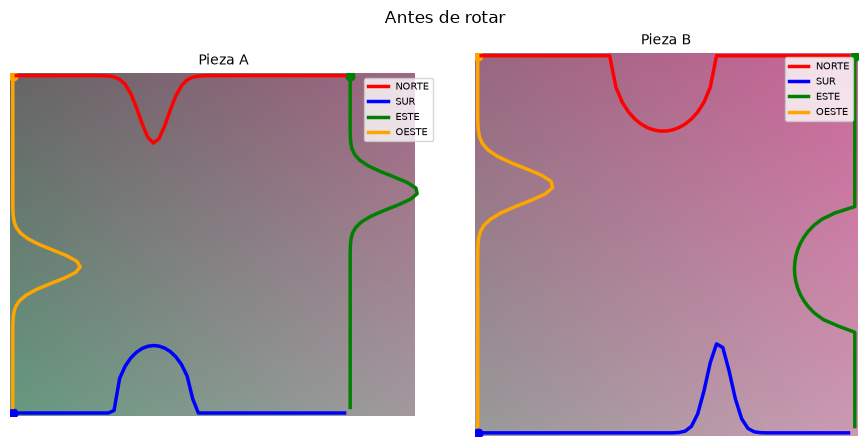

longitud borde ESTE de A: 60  longitud borde OESTE de B: 60


In [4]:
graficar_par(pieza_a, pieza_b, "Antes de rotar")

este_a = pieza_a.geometria.desviacion_borde("ESTE")
oeste_b = pieza_b.geometria.desviacion_borde("OESTE")
print("longitud borde ESTE de A:", len(este_a), " longitud borde OESTE de B:", len(oeste_b))


## Comparar los perfiles de la costura compartida (ESTE de A vs OESTE de B)

Si estan bien alineados, el perfil de A y el de B invertido (`-oeste_b`) deberian ser
practicamente el mismo (una es el molde macho, la otra el hembra).

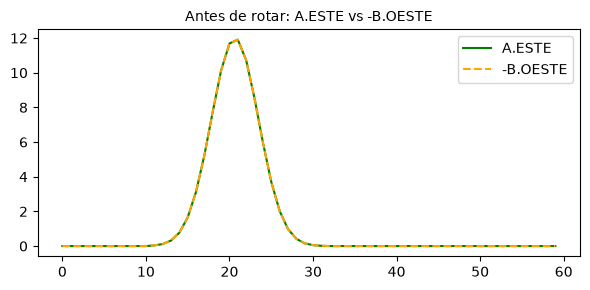

correlacion = 1.000  (esperado: cercano a +1.0 si encastran)


In [5]:
def graficar_perfiles(pieza_a, lado_a, pieza_b, lado_b, titulo):
    perfil_a = np.asarray(pieza_a.geometria.desviacion_borde(lado_a), dtype=np.float64)
    perfil_b = -np.asarray(pieza_b.geometria.desviacion_borde(lado_b), dtype=np.float64)

    n = min(len(perfil_a), len(perfil_b))
    idx_a = np.linspace(0, len(perfil_a) - 1, n).astype(int)
    idx_b = np.linspace(0, len(perfil_b) - 1, n).astype(int)

    plt.figure(figsize=(6, 3))
    plt.plot(perfil_a[idx_a], label=f"A.{lado_a}", color="green")
    plt.plot(perfil_b[idx_b], label=f"-B.{lado_b}", color="orange", linestyle="--")
    plt.title(titulo, fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()

    norma_a, norma_b = np.linalg.norm(perfil_a[idx_a]), np.linalg.norm(perfil_b[idx_b])
    correlacion = float(perfil_a[idx_a] @ perfil_b[idx_b] / (norma_a * norma_b)) if norma_a > 1e-6 and norma_b > 1e-6 else 0.0
    print(f"correlacion = {correlacion:.3f}  (esperado: cercano a +1.0 si encastran)")


graficar_perfiles(pieza_a, "ESTE", pieza_b, "OESTE", "Antes de rotar: A.ESTE vs -B.OESTE")


## Rotar ambas piezas y volver a mirar

Usamos un angulo chico y arbitrario (no hace falta el estimador de Fourier del Nivel 5
para ver el problema: alcanza con rotar y re-detectar).

In [ ]:
ANGULO_PRUEBA = 15.0

angulo_a_antes = pieza_a.angulo
angulo_b_antes = pieza_b.angulo

pieza_a.rotar(ANGULO_PRUEBA)
pieza_b.rotar(ANGULO_PRUEBA)

print(f"pieza_a.angulo: {angulo_a_antes} -> {pieza_a.angulo}")
print(f"pieza_b.angulo: {angulo_b_antes} -> {pieza_b.angulo}")


pieza_a.angulo: 0 -> 25.0
pieza_b.angulo: 0 -> 25.0


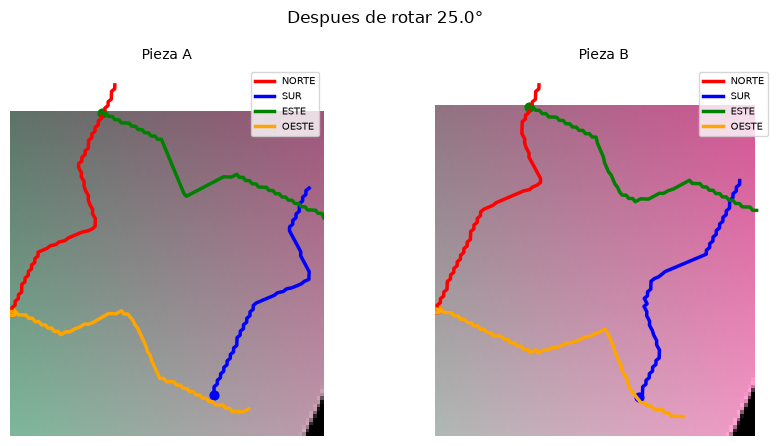

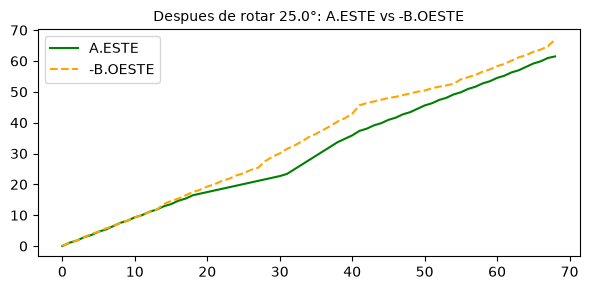

correlacion = 0.998  (esperado: cercano a +1.0 si encastran)


In [7]:
graficar_par(pieza_a, pieza_b, f"Despues de rotar {ANGULO_PRUEBA}°")
graficar_perfiles(pieza_a, "ESTE", pieza_b, "OESTE", f"Despues de rotar {ANGULO_PRUEBA}°: A.ESTE vs -B.OESTE")


## Deshacer la rotacion y ver si vuelve a alinear

Si el problema es puramente de re-etiquetado (no de que la forma en si se rompa), rotar
de vuelta el angulo exacto deberia devolver algo muy parecido al estado original.

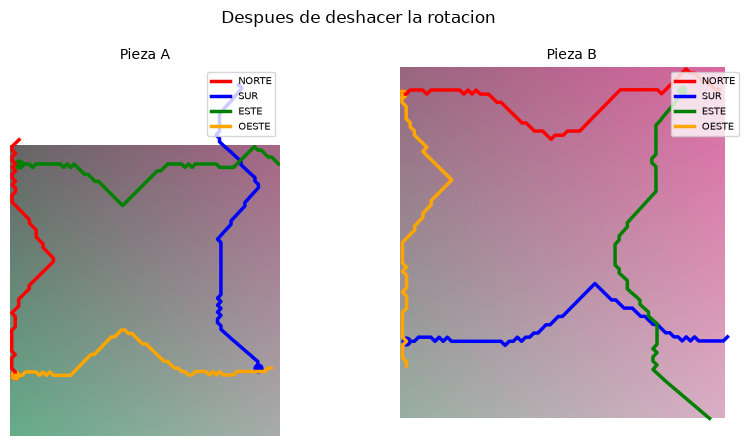

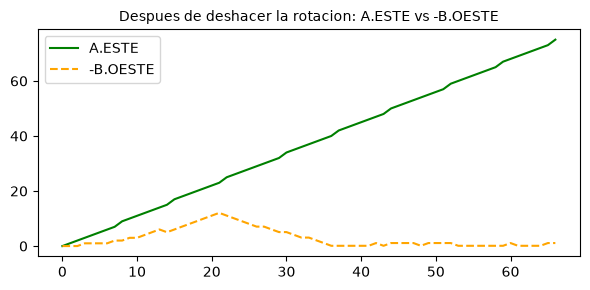

correlacion = 0.386  (esperado: cercano a +1.0 si encastran)


In [8]:
pieza_a.rotar(-ANGULO_PRUEBA)
pieza_b.rotar(-ANGULO_PRUEBA)

graficar_par(pieza_a, pieza_b, "Despues de deshacer la rotacion")
graficar_perfiles(pieza_a, "ESTE", pieza_b, "OESTE", "Despues de deshacer la rotacion: A.ESTE vs -B.OESTE")
